# 第45篇 | 逻辑回归：分类问题的"回归"解法

> 这是「数据分析从入门到精通」系列的第 45 篇。正则化学完了，这篇来解锁一个"名不副实"的算法——逻辑回归。它叫回归，做的却是分类，是机器学习里最基础也最常用的分类模型，面试必考。

嗨，我是小荷～ 今天学一个名字容易让人误解的算法：**逻辑回归**。它虽然叫"回归"，但其实是做**分类**的！就像萧何虽然是个文官，但打仗也有一套，不能只看名字嘛～

---

## 一、为什么叫"回归"却做分类？

**核心思想**：用回归的方法预测"属于某类的概率"，然后按概率分类。

我们先来看个例子，看如何用逻辑回归做个简单的二分类。

代码说明：

1. 生成一组模拟二分类数据（类别0：蓝色，类别1：红色）
2. 使用逻辑回归模型训练，计算每个样本属于类别1的概率
3. 在散点图上为每个点标注概率值
4. 直观展示：离分类边界越近，概率越接近0.5


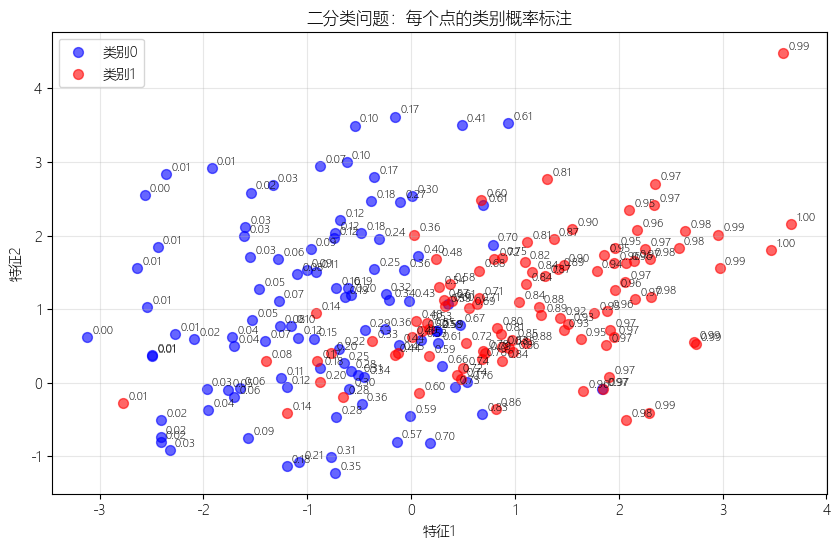

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression  # 必须加！

plt.rcdefaults()
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 生成二分类数据
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0, 
                           n_informative=2, n_clusters_per_class=1, 
                           random_state=42)

# ===================== 训练逻辑回归模型 =====================
model = LogisticRegression()
model.fit(X, y)

# 计算每个点属于【类别1】的概率
probabilities = model.predict_proba(X)[:, 1]  # 取出类别1的概率

# ===================== 可视化 + 显示概率 =====================
plt.figure(figsize=(10, 6))

# 画两类点
plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', label='类别0', alpha=0.6, s=50)
plt.scatter(X[y==1, 0], X[y==1, 1], c='red', label='类别1', alpha=0.6, s=50)

# ===================== 给每个点加上概率文字标注 =====================
for i, (x1, x2) in enumerate(X):
    prob = probabilities[i]
    # 在每个点旁边显示概率，保留2位小数
    plt.text(x1 + 0.05, x2 + 0.05, f"{prob:.2f}", fontsize=8, color="black")

plt.xlabel('特征1')
plt.ylabel('特征2')
plt.title('二分类问题：每个点的类别概率标注')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

效果说明：

- 红色点：类别 1（概率接近 1.00）
- 蓝色点：类别 0（概率接近 0.00）
- 中间的点：模棱两可，概率在 0.5 左右
- 每个点右上角数字：模型计算出的属于类别 1 的概率

---

## 二、Sigmoid 函数：把任何数变成概率

逻辑回归的核心是 **Sigmoid 函数**：

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$


它能把 $(-\infty, +\infty)$ 映射到 $(0, 1)$，正好表示概率！

它的形状是一条完美的 S 型曲线（如下面代码生成的图），拥有极其迷人的数学特性：
- 当 z 趋近于正无穷时，S(z) 趋近于 1。
- 当 z 趋近于负无穷时，S(z) 趋近于 0。
- 当 z = 0 时，S(z) 刚好等于 0.5（也就是分类的黄金分界线）。
 
通过这层转化，无论你的线性方程算出来的 z 是几万还是负几亿，经过 Sigmoid 的压制后，都会被死死压缩在 0 到 1 之间。这个输出的数值，在业务上就被完美地解释为“发生某件事的概率（Probability）”。

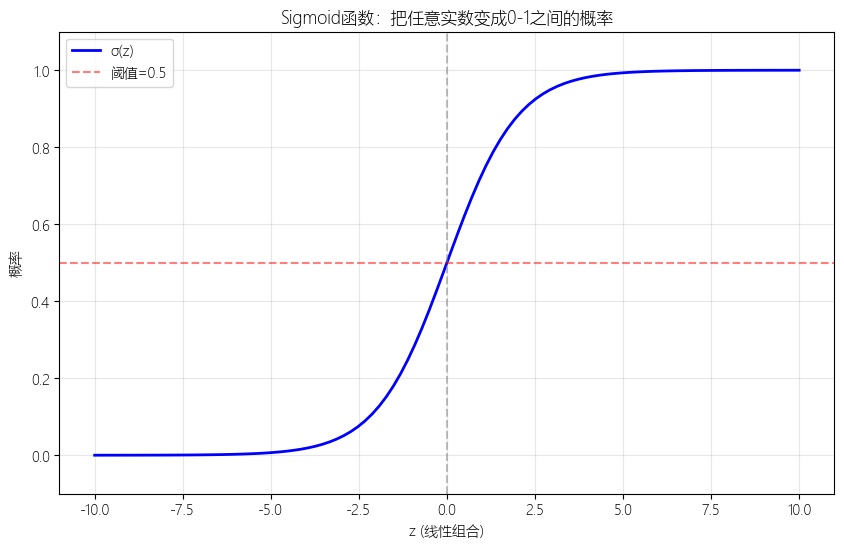

In [4]:
# Sigmoid函数可视化
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)

plt.figure(figsize=(10, 6))
plt.plot(z, sigmoid(z), 'b-', linewidth=2, label='σ(z)')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='阈值=0.5')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('z (线性组合)')
plt.ylabel('概率')
plt.title('Sigmoid函数：把任意实数变成0-1之间的概率')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.1)
plt.show()

---

## 三、逻辑回归的原理

**1. 什么是 Odds（几率）？**

逻辑回归在数学上还有一个非常优雅的解释，那就是几率（Odds）。

在博彩和统计学中，几率代表“一件事情发生的概率”与“不发生概率”的比值：

$$\text{Odds} = \frac{p}{1-p}$$

如果我们对几率取一个自然对数（Log），就会得到一个惊人的数学巧合。把 $p = \frac{1}{1 + e^{-z}}$ 代入进去：$$\ln\left(\frac{p}{1-p}\right) = z = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p$$这个左边叫做 Log-odds（或 Logit）。发现了吗？逻辑回归的本质，其实就是在用普通的线性回归，去拟合 **“某件事发生几率的对数”**！ 斜率 $\beta_1$ 的商业含义（面试高频考点）：**在逻辑回归中，当特征 $x_1$ 增加 1 个单位时，事件发生的几率（Odds）就会变成原来的 $e^{\beta_1}$ 倍。** 这也就是著名的医疗和金融领域“风险比/优势比（Odds Ratio, OR）”的来源。

**2. 损失函数：交叉熵损失（Cross-Entropy / Log Loss）**

既然逻辑回归的输出是概率，我们就不能再用普通线性回归的“残差平方和（最小二乘法）”来指导它训练了，因为此时的损失函数曲线会变成充满锯齿的非凸函数，梯度下降很容易卡死在局部最优解。逻辑回归使用的是大名鼎鼎的 最大似然估计（MLE）思想，对应的损失函数叫做 交叉熵损失（Cross-Entropy Loss）：$$\text{Loss} = - \frac{1}{n} \sum_{i=1}^{n} \left[ y_i \ln(\hat{y}_i) + (1 - y_i) \ln(1 - \hat{y}_i) \right]$$这个公式看起来很吓人，但拆开逻辑极其简单：如果一个样本的真实标签 $y = 1$（生病），公式后半部分归零，只剩 $- \ln(\hat{y}_i)$。如果模型预测的概率 $\hat{y}$ 越接近 1，损失就越接近 0；如果预测接近 0，损失就会暴涨到无穷大。如果真实标签 $y = 0$（健康），公式前半部分归零，如果预测接近 0 则无惩罚，预测接近 1 则重罚。这个损失函数是一个非常漂亮的凸函数（碗状），我们可以放心地使用梯度下降法（Gradient Descent），一路顺滑地滚到最底端，找到那组最完美的系数 $\beta$。

**3. 逻辑回归预测公式**：

$$
P(y=1|x) = \sigma(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + ...)
$$
P(y=1|x)的意思是：当我知道了这个用户的特征数据 $x$ 时，他触发目标行为（$y=1$）的概率是多少。

**4. 决策规则**：
- $P \geq 0.5$ → 预测为类别1
- $P < 0.5$ → 预测为类别0


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 划分数据，继续用上面的二分类数据
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 训练逻辑回归
lr = LogisticRegression()
lr.fit(X_train, y_train)

# 查看系数
print(f"截距: {lr.intercept_[0]:.4f}")
print(f"系数: {lr.coef_[0]}")
print(f"\n决策边界方程: {lr.intercept_[0]:.4f} + {lr.coef_[0][0]:.4f}*x1 + {lr.coef_[0][1]:.4f}*x2 = 0")


截距: 0.4670
系数: [ 1.80075398 -0.49370202]

决策边界方程: 0.4670 + 1.8008*x1 + -0.4937*x2 = 0


把决策边界画出来，直观感受一下逻辑回归是怎么划线的：


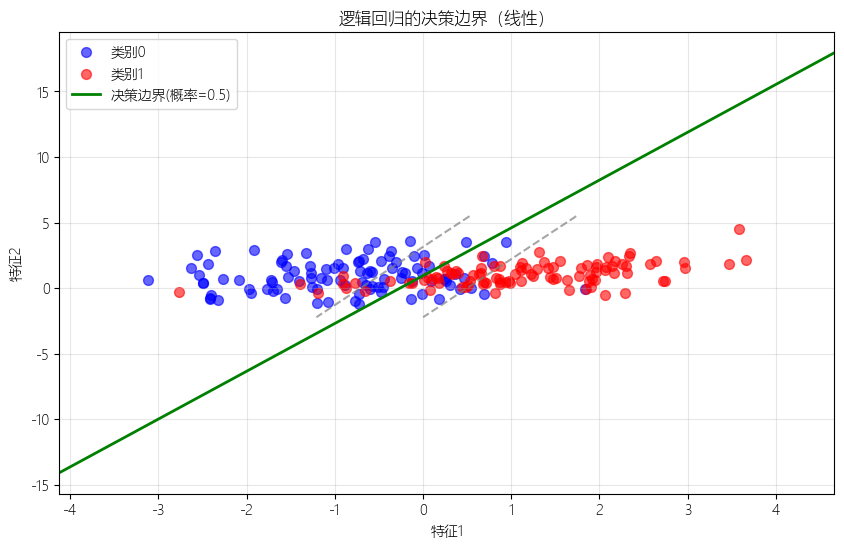

In [23]:
# 可视化决策边界
plt.figure(figsize=(10, 6))

# 画数据点
plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', label='类别0', alpha=0.6, s=50)
plt.scatter(X[y==1, 0], X[y==1, 1], c='red', label='类别1', alpha=0.6, s=50)

# 画决策边界
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x1_values = np.linspace(x1_min, x1_max, 100)
# 从 β₀ + β₁x₁ + β₂x₂ = 0 解出 x₂
x2_values = -(lr.intercept_[0] + lr.coef_[0][0] * x1_values) / lr.coef_[0][1]
plt.plot(x1_values, x2_values, 'g-', linewidth=2, label='决策边界(概率=0.5)')

# --------------------------
# 绘制概率等高线（0.25, 0.75）
# --------------------------
xx, yy = np.meshgrid(np.linspace(x1_min, x1_max, 100),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 100))
Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)
plt.contour(xx, yy, Z, levels=[0.25, 0.75], colors=['gray','gray'], linestyles='--', alpha=0.7)

plt.xlabel('特征1')
plt.ylabel('特征2')
plt.title('逻辑回归的决策边界（线性）')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(x1_min, x1_max)
plt.show()

---

## 四、模型评估：不只是准确率

1. **先明确二分类基础概念（混淆矩阵）**

二分类定义正负样本：类别 1 = 正例，类别 0 = 负例
混淆矩阵格式：
|真实 | 预测|	预测为正 (1)	|预测为负 (0)|
|--|---|---|---|
|真实为正| (1)|	TP (真正例)|	FN (假负例)|
|真实为负| (0)|	FP (假正例)	|TN (真负例)|

下面用 TP=25, FN=1, FP=7, TN=27, 总样本=25+1+7+27=60的数据，来解释下核心指标的含义。

2. 五大核心指标
    1. 准确率 Accuracy
       - 含义：所有样本中预测正确的比例，反映模型整体猜对的能力。
       - 公式：Accuracy = (TP+TN)/(TP+TN+FP+FN)
       - 计算： Accuracy = (25+27)/60 ≈ 0.87
    2. 精确率 Precision（查准率）
       - 含义：针对某一类，公式分正、负例
       - 公式：正例 (类别 1)  Precision = TP/(TP+FP) ,负例 (类别 0)  Precision = TN/(TN+FN)
       - 计算：正例 (类别 1)Precision = 25/(25+7) ≈ 0.78； 负例 (类别 0)Precision = 27/(27+1) ≈ 0.96
    3. 召回率 Recall（查全率 / 灵敏度）
       - 含义：真实属于该类的样本里，被模型成功找出的比例。
       - 公式：正例 (类别 1)  Recall = TP/(TP+FN) ,负例 (类别 0)  Recall = TN/(TN+FP)
       - 计算：正例 (类别 1)Recall = 25/(25+1) ≈ 0.96；负例 (类别 0)Recall = 27/(27+7) ≈ 0.79
    4. F1-Score
       - 含义：精确率和召回率的调和平均数
       - 公式：正例 (类别 1)  F1 = 2*Precision*Recall/(Precision+Recall) 
       - 计算：正例 (类别 1)F1 = 2*0.78*0.96/(0.78+0.96) ≈ 0.87；负例 (类别 0)F1 = 2*0.96*0.79/(0.78+0.96) ≈ 0.86
    5. 均值指标（macro /weighted avg）
       - macro avg（宏平均）：直接对每一类的 P/R/F1算术平均，不考虑样本数量。适合各类样本数量均衡的场景。
       - weighted avg（加权平均）：按每类样本占比加权计算均值，样本多的类别权重更大。适合样本不均衡场景，也是工业界最常用的整体评价指标。
    6. support = 该类别在测试集中的真实样本数量
        - 含义：就是每一类实际有多少条数据，用来判断样本分布是否均衡。

下面我们用训练好的逻辑回归模型做预测，然后打印出所有模型评估指标，分析一下模型准不准。

In [8]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc)

# 预测
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]  # 类别1的概率

# 基础指标
print("=" * 40)
print("分类报告:")
print(classification_report(y_test, y_pred, target_names=['类别0', '类别1']))

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
print("\n混淆矩阵:")
print(cm)
print(f"\n真正例(TP): {cm[1,1]}, 假正例(FP): {cm[0,1]}")
print(f"真负例(TN): {cm[0,0]}, 假负例(FN): {cm[1,0]}")


分类报告:
              precision    recall  f1-score   support

         类别0       0.96      0.79      0.87        34
         类别1       0.78      0.96      0.86        26

    accuracy                           0.87        60
   macro avg       0.87      0.88      0.87        60
weighted avg       0.88      0.87      0.87        60


混淆矩阵:
[[27  7]
 [ 1 25]]

真正例(TP): 25, 假正例(FP): 7
真负例(TN): 27, 假负例(FN): 1


文字看不够直观？画个热力图版本的混淆矩阵：


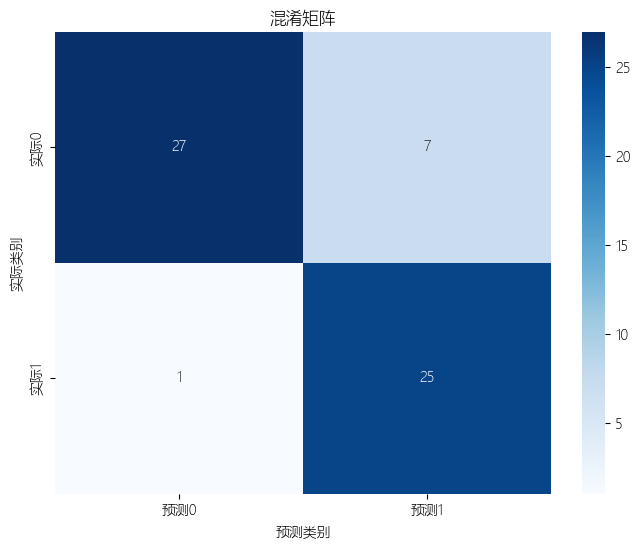

In [9]:
# 可视化混淆矩阵
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['预测0', '预测1'],
            yticklabels=['实际0', '实际1'])
plt.ylabel('实际类别')
plt.xlabel('预测类别')
plt.title('混淆矩阵')
plt.show()

分类报告指标解读：
1. precision 精确率（查准率） 
  - 类别 0 precision=0.96：预测成 0 的，96% 都是真 0； 类别 1 precision=0.78：预测成 1 的，78% 都是真 1
  - 说明：模型预测 “类别 0” 非常准，几乎不乱猜

2. recall 召回率（查全率）
  - 类别 0 recall=0.79：真 0 里，只找回 79%；类别 1 recall=0.96：真 1 里，找回 96%
  - 说明：模型几乎能找到所有 “类别 1”，几乎不漏掉
3. f1-score， precision 和 recall 的综合分数
  - 类别 0：0.87； 类别 1：0.86
  - 说明：两个类别表现均衡
4. accuracy 准确率
  - 0.87 → 87% 都猜对了！
  - 说明：整体效果非常好
三、这份报告到底说明了什么？（最关键）
  - 模型整体非常强：准确率 87%
  - 模型特别擅长找出 “类别 1”（recall=96%，几乎不漏）
  - 模型预测 “类别 0” 特别准（precision=96%，几乎不误判）
  - 唯一小缺点：把 7 个真实 0 误判成 1（FP=7）

---

## 五、ROC曲线与AUC

ROC 曲线是评估分类模型的好工具，ROC 曲线是模型在不同阈值下的表现，AUC 面积越大，分类能力越强。

怎么看图？（超级简单）

 - 曲线越靠近左上角 → 模型越好
 - AUC 越接近 1 → 分类能力越强
 - AUC = 0.5 → 跟随机猜一样
 - AUC < 0.5 → 比瞎猜还烂

下面我们画一条 ROC 曲线，评价一下二分类模型好不好、区分能力强不强。

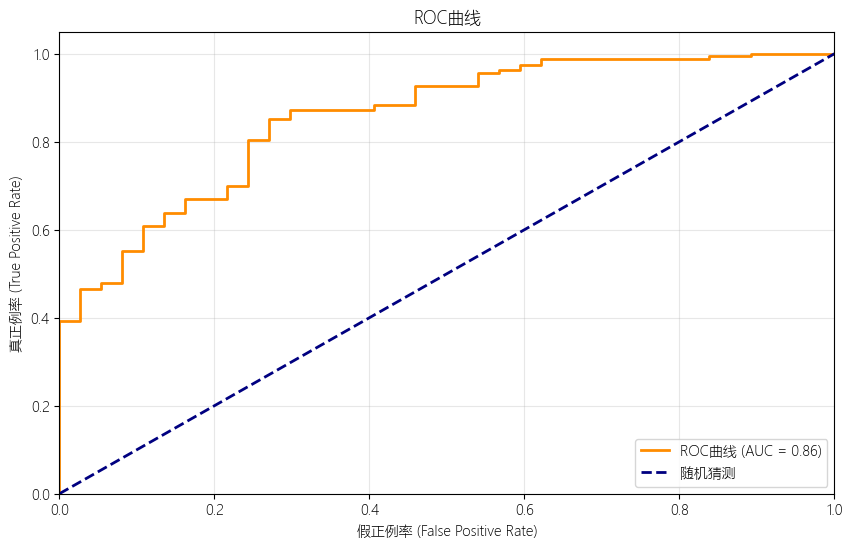

In [30]:
# ROC曲线
# y_test：真实类别（0/1）；y_prob：模型预测的类别 1 概率
# fpr：假正例率（错误把负类判成正类的比例）
# tpr：真正例率（正确找出正类的比例，就是召回率）
# thresholds：不同的分类阈值（0.5、0.6、0.3…）
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr) # 计算 AUC 面积

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC曲线 (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='随机猜测')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假正例率 (False Positive Rate)')
plt.ylabel('真正例率 (True Positive Rate)')
plt.title('ROC曲线')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

AUC = 0.86, 分类能力不错了。

---

## 六、多分类问题

逻辑回归也能处理多分类！


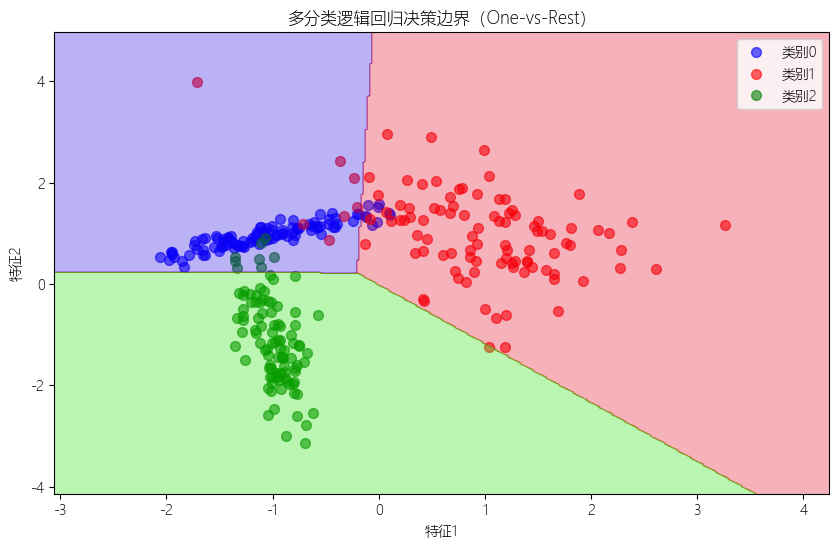

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

# 生成三分类数据
X_multi, y_multi = make_classification(
    n_samples=300, n_features=2, n_redundant=0,
    n_informative=2, n_clusters_per_class=1,
    n_classes=3, random_state=42
)

# 多分类逻辑回归
lr_multi = LogisticRegression(max_iter=1000)
lr_multi.fit(X_multi, y_multi)

# 可视化决策边界
plt.figure(figsize=(10, 6))
colors = ['blue', 'red', 'green']

for i in range(3):
    plt.scatter(
        X_multi[y_multi == i, 0], X_multi[y_multi == i, 1],
        c=colors[i], label=f'类别{i}', alpha=0.6, s=50
    )

# 画网格预测背景
h = 0.02
x_min, x_max = X_multi[:, 0].min() - 1, X_multi[:, 0].max() + 1
y_min, y_max = X_multi[:, 1].min() - 1, X_multi[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = lr_multi.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='brg')

plt.xlabel('特征1')
plt.ylabel('特征2')
plt.title('多分类逻辑回归决策边界（One-vs-Rest）')
plt.legend()
plt.show()

---

## 七、综合实战：客户购买预测

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：


In [14]:
# 模拟电商数据
np.random.seed(42)
n = 1000

# 特征
data = pd.DataFrame({
    '浏览时长': np.random.exponential(10, n),  # 分钟
    '页面深度': np.random.poisson(5, n),      # 浏览页面数
    '是否会员': np.random.binomial(1, 0.3, n),
    '历史订单': np.random.poisson(2, n),
    '购物车商品数': np.random.poisson(1, n)
})

# 生成购买标签（逻辑：浏览久+会员+有购物车 → 更可能购买）
logit = (-3 + 0.1*data['浏览时长'] + 0.3*data['页面深度'] + 
         1.5*data['是否会员'] + 0.5*data['历史订单'] + 1.0*data['购物车商品数'])
prob = sigmoid(logit)
data['是否购买'] = (np.random.random(n) < prob).astype(int)

print("数据预览:")
print(data.head(10))
print(f"\n购买率: {data['是否购买'].mean():.1%}")


数据预览:
        浏览时长  页面深度  是否会员  历史订单  购物车商品数  是否购买
0   4.692681     8     1     4       2     1
1  30.101214     4     1     2       2     1
2  13.167457     5     1     3       2     1
3   9.129426    10     0     3       2     1
4   1.696249     3     0     1       1     1
5   1.695963     4     0     0       0     0
6   0.598388     7     1     1       0     1
7  20.112309     5     1     2       0     1
8   9.190822    10     1     2       0     1
9  12.312501     4     0     4       3     1

购买率: 77.8%


数据准备好了，开始训练逻辑回归模型：


In [15]:
# 训练模型
X = data.drop('是否购买', axis=1)
y = data['是否购买']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 逻辑回归
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 预测
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n模型评估:")
print(f"准确率: {accuracy_score(y_test, y_pred):.3f}")
print(f"精确率: {precision_score(y_test, y_pred):.3f}")
print(f"召回率: {recall_score(y_test, y_pred):.3f}")
print(f"F1分数: {f1_score(y_test, y_pred):.3f}")



模型评估:
准确率: 0.830
精确率: 0.896
召回率: 0.896
F1分数: 0.896


模型指标不错，再看看哪些特征对购买决策影响最大：



特征重要性:
       特征        系数  odds_ratio
2    是否会员  1.289349    3.630421
4  购物车商品数  0.898212    2.455209
3    历史订单  0.444439    1.559616
1    页面深度  0.289875    1.336260
0    浏览时长  0.110254    1.116561


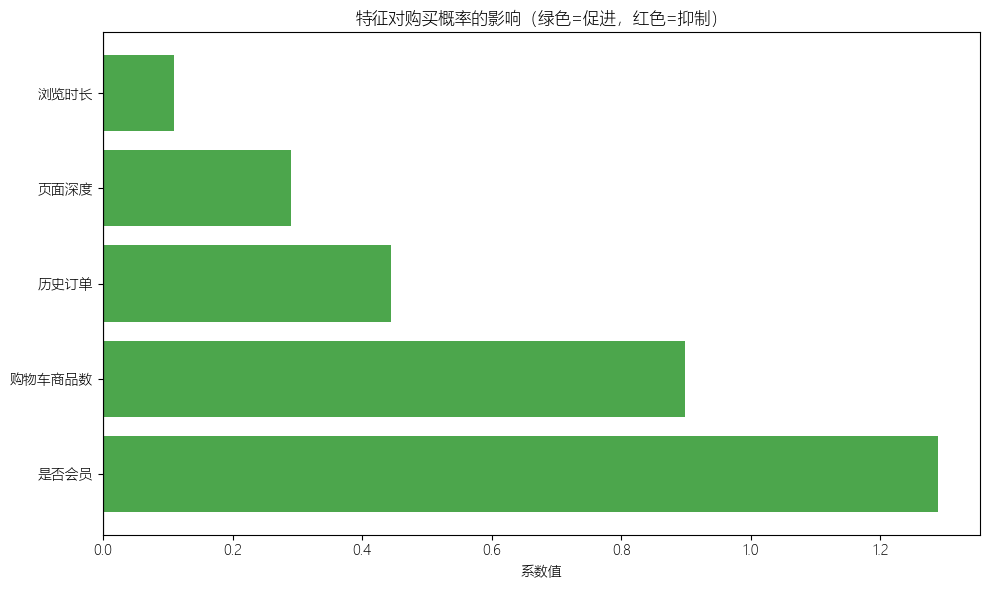

In [17]:
# 特征重要性（系数）
feature_importance = pd.DataFrame({
    '特征': X.columns,
    '系数': model.coef_[0],
    'odds_ratio': np.exp(model.coef_[0])  # 发生比
}).sort_values('系数', key=abs, ascending=False)

print("\n特征重要性:")
print(feature_importance)

# 可视化
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in feature_importance['系数']]
plt.barh(feature_importance['特征'], feature_importance['系数'], color=colors, alpha=0.7)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.xlabel('系数值')
plt.title('特征对购买概率的影响（绿色=促进，红色=抑制）')
plt.tight_layout()
plt.show()


最后再看看模型输出的预测概率分布——好的模型应该把两类的概率尽量分开：


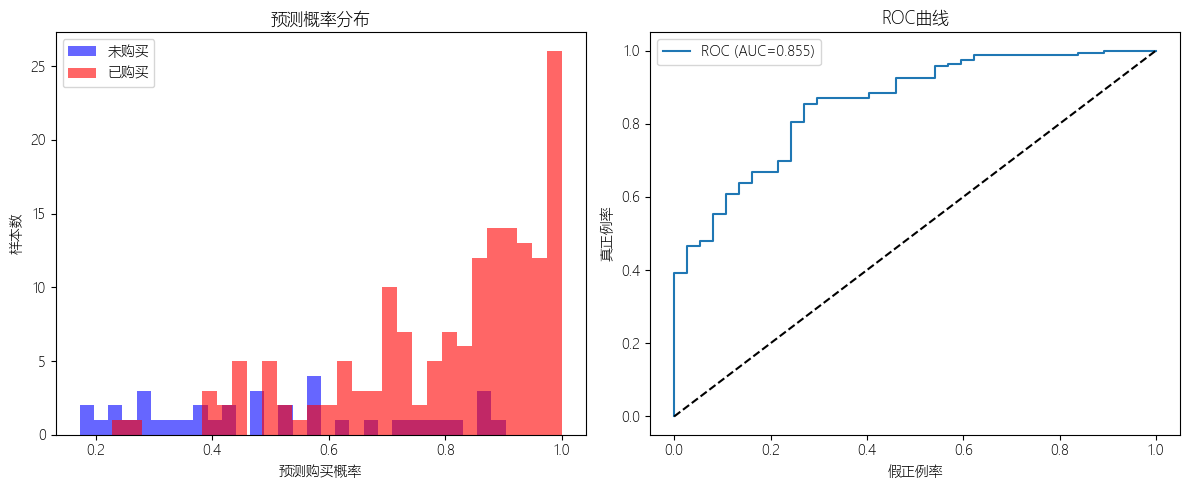

In [18]:
# 预测概率分布
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(y_prob[y_test==0], bins=30, alpha=0.6, label='未购买', color='blue')
plt.hist(y_prob[y_test==1], bins=30, alpha=0.6, label='已购买', color='red')
plt.xlabel('预测购买概率')
plt.ylabel('样本数')
plt.title('预测概率分布')
plt.legend()

plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'ROC (AUC={roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('假正例率')
plt.ylabel('真正例率')
plt.title('ROC曲线')
plt.legend()

plt.tight_layout()
plt.show()

---

## 八、小结

| 概念 | 说明 |
|------|------|
| **Sigmoid** | 将线性输出转为0-1概率 |
| **决策边界** | $P=0.5$ 对应的超平面 |
| **Odds Ratio** | $e^\beta$，表示特征增加1单位，发生比的变化倍数 |
| **阈值** | 默认0.5，可根据业务调整（如召回优先则降低阈值） |

**逻辑回归 vs 线性回归**：
- 线性回归：预测连续值，用MSE
- 逻辑回归：预测概率/分类，用对数似然

**适用场景**：
- 二分类问题（是否购买、是否流失、是否违约）
- 需要可解释性的场景（系数直接表示影响方向和大小）
- 特征与目标近似线性关系时效果较好

---

## 九、课后练习

1. 调整分类阈值（0.3、0.5、0.7），观察精确率和召回率的变化
2. 尝试用L1正则化的逻辑回归进行特征选择
3. 解释odds_ratio的含义：如果"是否会员"的odds_ratio是4.5，代表什么？

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             precision_recall_curve, classification_report)

# 设置中文字体和样式
plt.rcdefaults()
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 构造会员购买行为数据
np.random.seed(42)
n = 500

# 生成特征
age = np.random.normal(35, 10, n)                    # 年龄
income = np.random.normal(50, 15, n)                  # 月收入（千元）
online_time = np.random.exponential(3, n)              # 每日在线时长（小时）
purchase_history = np.random.randint(0, 20, n)         # 历史购买次数

# 生成目标变量（会员与否，与多个因素相关）
logit_p = (-5 + 0.1*age + 0.05*income + 0.3*online_time + 0.2*purchase_history)
prob = 1 / (1 + np.exp(-logit_p))
is_member = (np.random.random(n) < prob).astype(int)

print(f"样本总数: {n}")
print(f"会员数量: {is_member.sum()} ({is_member.mean()*100:.1f}%)")
print(f"非会员数量: {n - is_member.sum()} ({(1-is_member.mean())*100:.1f}%)")

# 创建数据框
df = pd.DataFrame({
    '年龄': age,
    '月收入(千元)': income,
    '在线时长(小时)': online_time,
    '历史购买次数': purchase_history,
    '是否会员': is_member
})

print("\n数据预览：")
print(df.describe().to_string())

# 准备特征和标签
features = ['年龄', '月收入(千元)', '在线时长(小时)', '历史购买次数']
X = df[features]
y = df['是否会员']

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

样本总数: 500
会员数量: 471 (94.2%)
非会员数量: 29 (5.8%)

数据预览：
               年龄     月收入(千元)    在线时长(小时)      历史购买次数        是否会员
count  500.000000  500.000000  500.000000  500.000000  500.000000
mean    35.068380   50.477392    3.060952    9.660000    0.942000
std      9.812532   14.669958    3.144365    5.848145    0.233978
min      2.587327    9.546700    0.014857    0.000000    0.000000
25%     27.996926   41.070624    0.818465    4.000000    1.000000
50%     35.127971   50.427974    2.145099   10.000000    1.000000
75%     41.367833   59.768634    4.001334   15.000000    1.000000
max     73.527315   89.485731   22.325169   19.000000    1.000000


练习1：不同阈值下的精确率和召回率
--------------------------------------------------

不同阈值下的模型性能：
----------------------------------------------------------------------
阈值       准确率          精确率          召回率          F1分数        
----------------------------------------------------------------------
0.3      0.9533       0.9533       1.0000       0.9761      
0.4      0.9533       0.9533       1.0000       0.9761      
0.5      0.9533       0.9533       1.0000       0.9761      
0.6      0.9467       0.9530       0.9930       0.9726      
0.7      0.9533       0.9595       0.9930       0.9759      

阈值分析：
- 阈值越低：预测为正类的样本越多，召回率↑，精确率↓
- 阈值越高：预测为正类的样本越少，召回率↓，精确率↑
- 需要根据业务场景选择合适的阈值


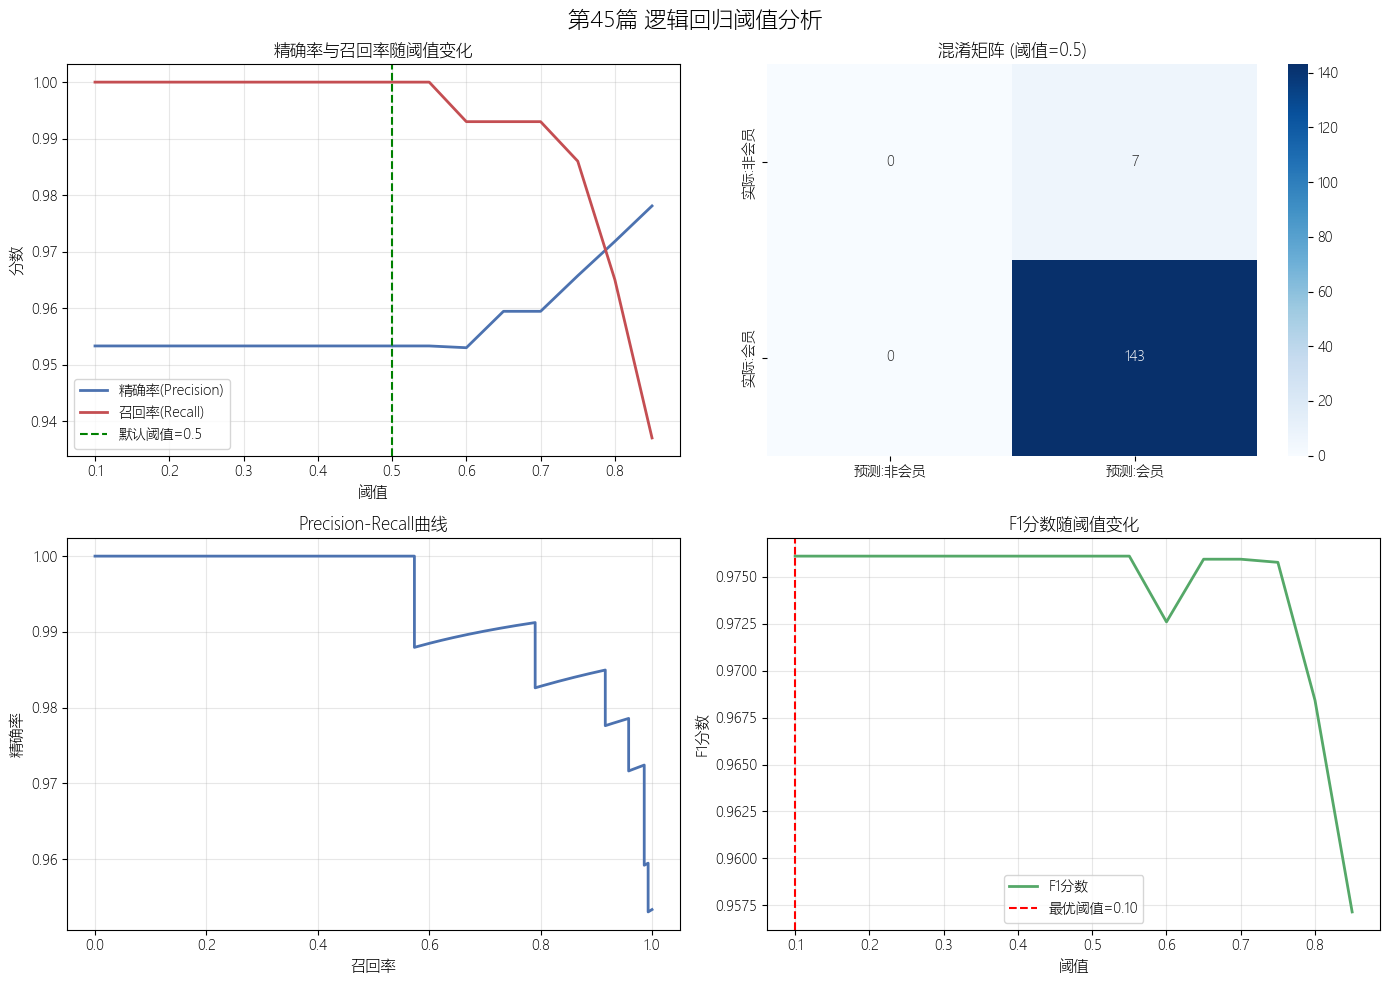

In [35]:
print("练习1：不同阈值下的精确率和召回率")
print("-" * 50)

# 训练逻辑回归模型
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# 获取预测概率
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# 测试不同阈值
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
results = []

print("\n不同阈值下的模型性能：")
print("-" * 70)
print(f"{'阈值':<8} {'准确率':<12} {'精确率':<12} {'召回率':<12} {'F1分数':<12}")
print("-" * 70)

for thresh in thresholds:
    y_pred = (y_proba >= thresh).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        'threshold': thresh,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    })
    print(f"{thresh:<8.1f} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")

print("\n阈值分析：")
print("- 阈值越低：预测为正类的样本越多，召回率↑，精确率↓")
print("- 阈值越高：预测为正类的样本越少，召回率↓，精确率↑")
print("- 需要根据业务场景选择合适的阈值")

# 可视化
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('第45篇 逻辑回归阈值分析', fontsize=16, fontweight='bold')

# 图1：精确率-召回率随阈值变化
ax1 = axes[0, 0]
thresholds_plot = np.arange(0.1, 0.9, 0.05)
precisions = []
recalls = []
for thresh in thresholds_plot:
    y_pred = (y_proba >= thresh).astype(int)
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred, zero_division=0))

ax1.plot(thresholds_plot, precisions, 'b-', linewidth=2, label='精确率(Precision)')
ax1.plot(thresholds_plot, recalls, 'r-', linewidth=2, label='召回率(Recall)')
ax1.axvline(x=0.5, color='green', linestyle='--', label='默认阈值=0.5')
ax1.set_xlabel('阈值', fontsize=11)
ax1.set_ylabel('分数', fontsize=11)
ax1.set_title('精确率与召回率随阈值变化', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 图2：混淆矩阵热力图（阈值=0.5）
ax2 = axes[0, 1]
y_pred_05 = (y_proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_05)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['预测:非会员', '预测:会员'],
            yticklabels=['实际:非会员', '实际:会员'])
ax2.set_title('混淆矩阵 (阈值=0.5)', fontsize=12)

# 图3：Precision-Recall曲线
ax3 = axes[1, 0]
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
ax3.plot(recall_curve, precision_curve, 'b-', linewidth=2)
ax3.set_xlabel('召回率', fontsize=11)
ax3.set_ylabel('精确率', fontsize=11)
ax3.set_title('Precision-Recall曲线', fontsize=12)
ax3.grid(True, alpha=0.3)

# 图4：F1分数随阈值变化
ax4 = axes[1, 1]
f1_scores = [2*p*r/(p+r) if (p+r) > 0 else 0 for p, r in zip(precisions, recalls)]
ax4.plot(thresholds_plot, f1_scores, 'g-', linewidth=2, label='F1分数')
best_thresh_idx = np.argmax(f1_scores)
best_thresh = thresholds_plot[best_thresh_idx]
ax4.axvline(x=best_thresh, color='red', linestyle='--', label=f'最优阈值={best_thresh:.2f}')
ax4.set_xlabel('阈值', fontsize=11)
ax4.set_ylabel('F1分数', fontsize=11)
ax4.set_title('F1分数随阈值变化', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


--------------------------------------------------
练习2：L1正则化逻辑回归特征选择
--------------------------------------------------

L1 vs L2正则化系数对比：
--------------------------------------------------
特征              L2系数            L1系数            L1淘汰?     
--------------------------------------------------
特征1             0.6770          0.6528          ✓ 保留      
特征2             0.7081          0.6899          ✓ 保留      
特征3             0.7178          0.6715          ✓ 保留      
特征4             0.8534          0.8399          ✓ 保留      


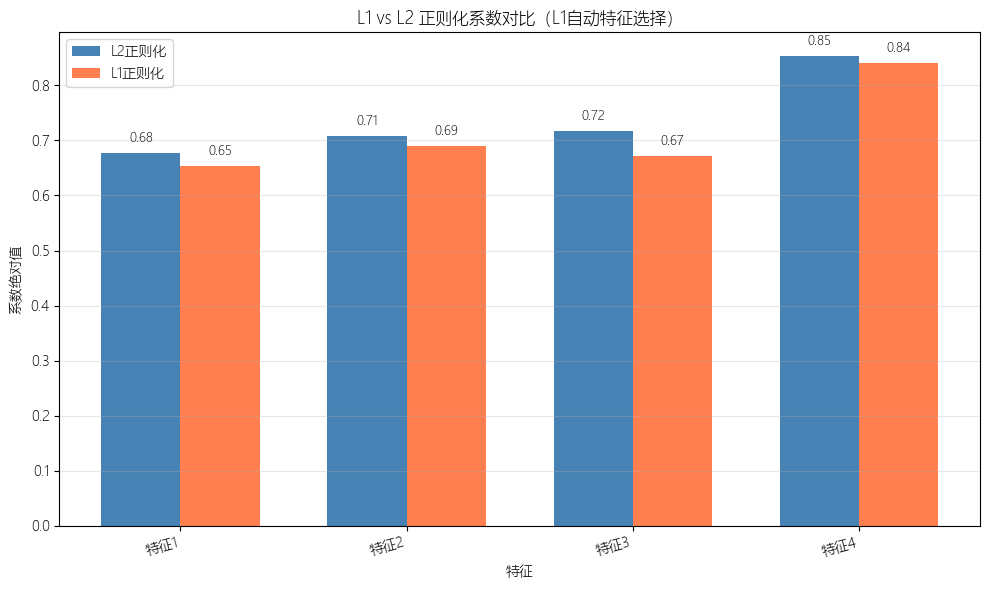


✅ L1保留的特征：['特征1', '特征2', '特征3', '特征4']
❌ L1淘汰的特征：[]


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# ============================================================
print("\n" + "-" * 50)
print("练习2：L1正则化逻辑回归特征选择")
print("-" * 50)

# 【修复】新版本写法：L1 正则化
model_l1 = LogisticRegression(
    solver='saga',
    l1_ratio=1,      # L1 = 1
    C=1.0,
    max_iter=2000,
    random_state=42
)
model_l1.fit(X_train_scaled, y_train)

# 【修复】默认是 L2 正则化
model_l2 = LogisticRegression(random_state=42)
model_l2.fit(X_train_scaled, y_train)

# 获取系数
coef_l1 = model_l1.coef_[0]
coef_l2 = model_l2.coef_[0]

# 打印对比
print("\nL1 vs L2正则化系数对比：")
print("-" * 50)
print(f"{'特征':<15} {'L2系数':<15} {'L1系数':<15} {'L1淘汰?':<10}")
print("-" * 50)

features = [f'特征{i+1}' for i in range(len(coef_l1))] # 如果没有定义features，用这个

for i, feat in enumerate(features):
    eliminated = "✗ 淘汰" if abs(coef_l1[i]) < 1e-6 else "✓ 保留"
    print(f"{feat:<15} {coef_l2[i]:<15.4f} {coef_l1[i]:<15.4f} {eliminated:<10}")

# 可视化系数对比
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(features))
width = 0.35

bars1 = ax.bar(x_pos - width/2, np.abs(coef_l2), width, label='L2正则化', color='steelblue')
bars2 = ax.bar(x_pos + width/2, np.abs(coef_l1), width, label='L1正则化', color='coral')

ax.set_xlabel('特征')
ax.set_ylabel('系数绝对值')
ax.set_title('L1 vs L2 正则化系数对比（L1自动特征选择）')
ax.set_xticks(x_pos)
ax.set_xticklabels(features, rotation=15, ha='right')
ax.legend()
ax.grid(alpha=0.3, axis='y')

# 显示数值
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 结果总结
eliminated = [f for i, f in enumerate(features) if abs(coef_l1[i]) < 1e-6]
kept = [f for i, f in enumerate(features) if abs(coef_l1[i]) >= 1e-6]

print(f"\n✅ L1保留的特征：{kept}")
print(f"❌ L1淘汰的特征：{eliminated}")


--------------------------------------------------
练习3：Odds Ratio的解释
--------------------------------------------------

各特征的Odds Ratio：
--------------------------------------------------
  特征1: OR = 1.9680 → 特征增加1单位，会员概率增加 96.8%
  特征2: OR = 2.0302 → 特征增加1单位，会员概率增加 103.0%
  特征3: OR = 2.0499 → 特征增加1单位，会员概率增加 105.0%
  特征4: OR = 2.3475 → 特征增加1单位，会员概率增加 134.8%

Odds Ratio 详解

问题：如果"是否会员"的Odds Ratio是4.5，代表什么？

解答：
----------------------------------------
Odds（赔率/优势）= P(会员) / P(非会员)
Odds Ratio (OR) = Odds₁ / Odds₀

假设某特征的OR = 4.5，意味着：
1. 当该特征增加1个单位时，会员的优势(odds)是原来的4.5倍
2. 即会员的概率增加了 350%
3. 例如：原来会员odds=1（50%概率），增加后odds=4.5（概率≈82%）

OR值的解读：
  OR = 1: 特征对会员概率无影响
  OR > 1: 特征增加会员概率（正向因素）
  OR < 1: 特征降低会员概率（负向因素）

--------------------------------------------------
额外内容：ROC曲线
--------------------------------------------------


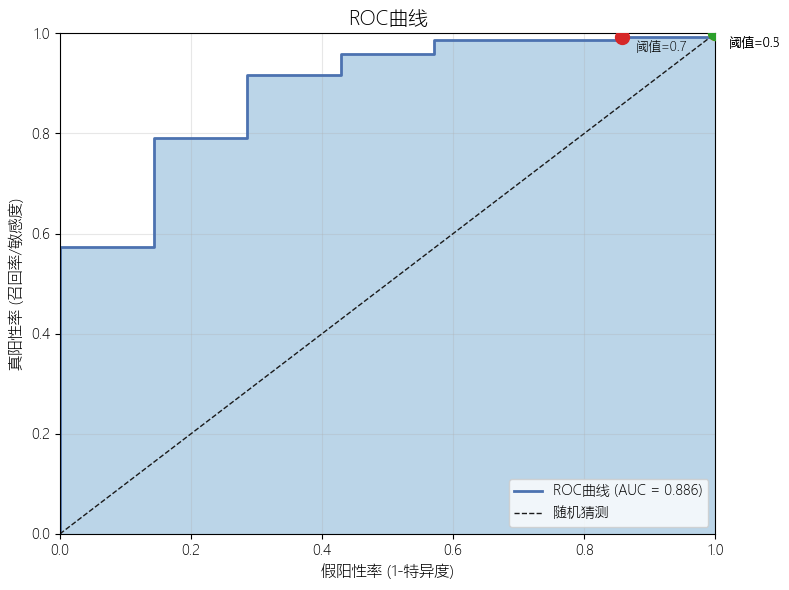


ROC-AUC分数: 0.8861

AUC解读：
  AUC = 1.0: 完美分类器
  AUC = 0.5: 随机猜测
  AUC > 0.8: 较好的分类器
  AUC > 0.9: 优秀的分类器

总结
1. 阈值越低→召回率越高，精确率越低；阈值越高则相反
2. L1正则化可以实现自动特征选择，将不重要特征的系数压为0
3. Odds Ratio衡量特征变化对会员优势的影响
4. ROC-AUC评估分类器整体性能，不受阈值选择影响


In [40]:
# 练习3：Odds Ratio的解释
# ============================================================
print("\n" + "-" * 50)
print("练习3：Odds Ratio的解释")
print("-" * 50)

# 计算Odds Ratio（对L2模型的系数）
odds_ratios = np.exp(coef_l2)

print("\n各特征的Odds Ratio：")
print("-" * 50)
for feat, or_val in zip(features, odds_ratios):
    if or_val > 1:
        change = (or_val - 1) * 100
        print(f"  {feat}: OR = {or_val:.4f} → 特征增加1单位，会员概率增加 {change:.1f}%")
    else:
        change = (1 - or_val) * 100
        print(f"  {feat}: OR = {or_val:.4f} → 特征增加1单位，会员概率降低 {change:.1f}%")

print("\n" + "=" * 50)
print("Odds Ratio 详解")
print("=" * 50)
print("\n问题：如果\"是否会员\"的Odds Ratio是4.5，代表什么？")
print("\n解答：")
print("-" * 40)
print("Odds（赔率/优势）= P(会员) / P(非会员)")
print("Odds Ratio (OR) = Odds₁ / Odds₀")
print("")
print("假设某特征的OR = 4.5，意味着：")
print("1. 当该特征增加1个单位时，会员的优势(odds)是原来的4.5倍")
print("2. 即会员的概率增加了 350%")
print("3. 例如：原来会员odds=1（50%概率），增加后odds=4.5（概率≈82%）")
print("")
print("OR值的解读：")
print("  OR = 1: 特征对会员概率无影响")
print("  OR > 1: 特征增加会员概率（正向因素）")
print("  OR < 1: 特征降低会员概率（负向因素）")

# ============================================================
# 额外：ROC曲线可视化
# ============================================================
print("\n" + "-" * 50)
print("额外内容：ROC曲线")
print("-" * 50)

# 计算ROC曲线
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# 绘制ROC曲线
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC曲线 (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='随机猜测')
ax.fill_between(fpr, tpr, alpha=0.3)

# 标注几个关键阈值点
key_thresholds = [0.3, 0.5, 0.7]
for thresh in key_thresholds:
    idx = np.argmin(np.abs(roc_thresholds - thresh))
    ax.scatter(fpr[idx], tpr[idx], s=100, zorder=5)
    ax.annotate(f'阈值={thresh}', (fpr[idx], tpr[idx]),
                textcoords="offset points", xytext=(10, -10), fontsize=9)

ax.set_xlabel('假阳性率 (1-特异度)', fontsize=11)
ax.set_ylabel('真阳性率 (召回率/敏感度)', fontsize=11)
ax.set_title('ROC曲线', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print(f"\nROC-AUC分数: {roc_auc:.4f}")
print("\nAUC解读：")
print("  AUC = 1.0: 完美分类器")
print("  AUC = 0.5: 随机猜测")
print("  AUC > 0.8: 较好的分类器")
print("  AUC > 0.9: 优秀的分类器")

print("\n" + "=" * 60)
print("总结")
print("=" * 60)
print("1. 阈值越低→召回率越高，精确率越低；阈值越高则相反")
print("2. L1正则化可以实现自动特征选择，将不重要特征的系数压为0")
print("3. Odds Ratio衡量特征变化对会员优势的影响")
print("4. ROC-AUC评估分类器整体性能，不受阈值选择影响")

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 46 篇：阶段大实战 — 房价预测完整项目**
>
> 回归分析的收官之作！做一个完整的房价预测项目，把线性回归、正则化、逻辑回归都用上。

---

*有任何问题，欢迎在评论区留言，小荷会一一回复的！*